# 05b: Ensemble Modeling — Blend of XGBoost + LightGBM + Logistic Regression

**Prerequisite:** Run `04a_feature_building.ipynb` then `04b_matchup_building.ipynb`

### Strategy
Train 3 different models, then blend their predictions:
- **XGBoost** — gradient-boosted trees (level-wise)
- **LightGBM** — gradient-boosted trees (leaf-wise)
- **Logistic Regression** — linear model with sigmoid (well-calibrated probabilities)

### Why Blend?
Different algorithms make different errors. Averaging them smooths out individual model weaknesses and produces more stable, better-calibrated probabilities.

### Evaluation: Brier Score
- Brier Score = mean((predicted - actual)²)
- 0.0 = perfect, 0.25 = coin flip
- Lower is better

---
## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss, accuracy_score, brier_score_loss
from sklearn.calibration import calibration_curve

from src.data_loader import load_sample_submission, load_teams, PROCESSED_DIR
from src.utils import validate_submission, parse_submission_id

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

pd.set_option('display.max_columns', None)

teams = load_teams('M')
team_lookup = dict(zip(teams['TeamID'], teams['TeamName']))

print(f"XGBoost: {xgb.__version__}")
print(f"LightGBM: {lgb.__version__}")

XGBoost: 3.2.0
LightGBM: 4.6.0


In [2]:
# Load matchup features (built in 04b)
matchups = pd.read_csv(PROCESSED_DIR / 'matchup_features.csv')
print(f"All matchups: {len(matchups):,} rows")
print(f"Seasons: {matchups['Season'].min()} to {matchups['Season'].max()}")
print(f"GameType: {matchups['GameType'].value_counts().to_dict()}")

# Load team features (for generating 2026 predictions)
team_features = pd.read_csv(PROCESSED_DIR / 'team_features.csv')
print(f"\nTeam features: {len(team_features):,} rows")

# Load sample submission
sample_sub = load_sample_submission(stage=2)
print(f"\nSample submission (2026): {len(sample_sub):,} rows")

All matchups: 118,311 rows
Seasons: 2003 to 2026
GameType: {'Regular': 116862, 'Tournament': 1449}

Team features: 8,346 rows

Sample submission (2026): 132,133 rows


---
## 2. Feature Selection & Train/Val Split

In [3]:
# Exclude highly correlated features (from correlation analysis in 04b)
drop_cols = ['SAG_Rank_Diff', 'POM_Rank_Diff', 'WinPct_Diff',
             'AvgPointsFor_Diff', 'AvgPointsAgainst_Diff', 'Last15WinPct_Diff']

feature_cols = [c for c in matchups.columns if c.endswith('_Diff') and c not in drop_cols]

matchups = matchups.drop(columns=drop_cols, errors='ignore')

print(f"Feature columns ({len(feature_cols)}):")
for col in feature_cols:
    print(f"  {col}")

Feature columns (12):
  AvgMargin_Diff
  eFG_Off_Diff
  TORate_Off_Diff
  ORBRate_Off_Diff
  FTRate_Off_Diff
  Elo_RegSeason_Diff
  Composite_Rank_Diff
  SeedNum_Diff
  IsSeeded_Diff
  ConfStrength_Rank_Diff
  Last15AvgMargin_Diff
  ConfTourneyChamp_Diff


In [4]:
# Time-based split
train_data = matchups[matchups['Season'] <= 2024].copy()
val_data = matchups[matchups['Season'] == 2025].copy()

# Drop NaN rows
train_clean = train_data.dropna(subset=feature_cols)
val_clean = val_data.dropna(subset=feature_cols)

X_train = train_clean[feature_cols]
y_train = train_clean['Target']

X_val = val_clean[feature_cols]
y_val = val_clean['Target']

# Tournament-only validation (the real test)
val_tourney = val_clean[val_clean['GameType'] == 'Tournament'].copy()
X_val_t = val_tourney[feature_cols]
y_val_t = val_tourney['Target']

print(f"Training:     {X_train.shape[0]:,} rows ({train_data['Season'].min()}-{train_data['Season'].max()})")
print(f"Validation:   {X_val.shape[0]:,} rows (2025 all games)")
print(f"Val Tourney:  {len(val_tourney)} rows (2025 tournament only)")
print(f"Features:     {X_train.shape[1]}")

Training:     108,758 rows (2003-2024)
Validation:   5,650 rows (2025 all games)
Val Tourney:  67 rows (2025 tournament only)
Features:     12


---
## 3. Model 1: XGBoost (Tuned)

In [5]:
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=2000,
    max_depth=4,             # reduced from 8 to prevent overfitting
    learning_rate=0.02,      # slower learning = better generalization
    subsample=0.75,
    colsample_bytree=0.75,
    min_child_weight=5,      # increased from 3
    reg_alpha=0.5,           # L1 regularization (new)
    reg_lambda=3.0,          # L2 regularization (increased)
    early_stopping_rounds=150,
    random_state=42,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100
)

print(f"\nBest iteration: {xgb_model.best_iteration}")
print(f"Best validation log loss: {xgb_model.best_score:.4f}")

[0]	validation_0-logloss:0.68943	validation_1-logloss:0.69092
[100]	validation_0-logloss:0.59792	validation_1-logloss:0.61128
[200]	validation_0-logloss:0.59125	validation_1-logloss:0.60707
[300]	validation_0-logloss:0.58937	validation_1-logloss:0.60627
[400]	validation_0-logloss:0.58798	validation_1-logloss:0.60599
[500]	validation_0-logloss:0.58673	validation_1-logloss:0.60580
[600]	validation_0-logloss:0.58553	validation_1-logloss:0.60577
[700]	validation_0-logloss:0.58445	validation_1-logloss:0.60574
[800]	validation_0-logloss:0.58338	validation_1-logloss:0.60590
[852]	validation_0-logloss:0.58280	validation_1-logloss:0.60591

Best iteration: 702
Best validation log loss: 0.6057


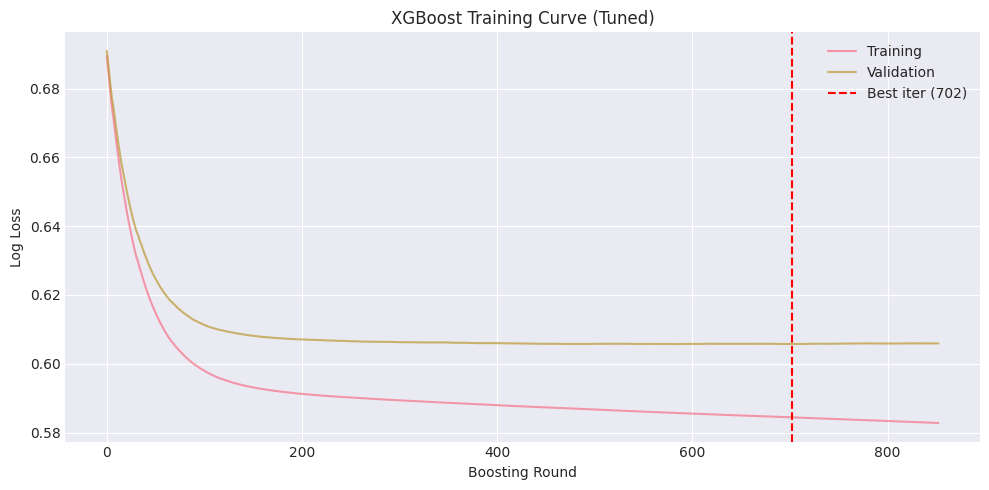

In [6]:
# XGBoost training curves
results_xgb = xgb_model.evals_result()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results_xgb['validation_0']['logloss'], label='Training', alpha=0.7)
ax.plot(results_xgb['validation_1']['logloss'], label='Validation', alpha=0.7)
ax.axvline(xgb_model.best_iteration, color='red', linestyle='--',
           label=f'Best iter ({xgb_model.best_iteration})')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Log Loss')
ax.set_title('XGBoost Training Curve (Tuned)')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# XGBoost tournament evaluation
xgb_preds_tourney = xgb_model.predict_proba(X_val_t)[:, 1]
xgb_brier = brier_score_loss(y_val_t, xgb_preds_tourney)
xgb_ll = log_loss(y_val_t, xgb_preds_tourney)
xgb_acc = accuracy_score(y_val_t, (xgb_preds_tourney > 0.5).astype(int))

print(f"XGBoost — 2025 Tournament:")
print(f"  Brier Score: {xgb_brier:.4f}")
print(f"  Log Loss:    {xgb_ll:.4f}")
print(f"  Accuracy:    {xgb_acc:.1%}")

XGBoost — 2025 Tournament:
  Brier Score: 0.1705
  Log Loss:    0.5095
  Accuracy:    76.1%


---
## 4. Model 2: Logistic Regression

In [8]:
# Logistic Regression needs scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_val_t_scaled = scaler.transform(X_val_t)

lr_model = LogisticRegression(
    C=0.5,                   # regularization (lower = more regularization)
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

lr_model.fit(X_train_scaled, y_train)

# Show feature weights
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Weight': lr_model.coef_[0]
}).sort_values('Weight', key=abs, ascending=False)

print("Logistic Regression coefficients:")
for _, row in coef_df.iterrows():
    direction = '+' if row['Weight'] > 0 else '-'
    print(f"  {direction} {row['Feature']}: {row['Weight']:.4f}")

Logistic Regression coefficients:
  - SeedNum_Diff: -1.7819
  - IsSeeded_Diff: -1.7350
  - Composite_Rank_Diff: -0.5811
  - ConfStrength_Rank_Diff: -0.4519
  + AvgMargin_Diff: 0.2818
  - Elo_RegSeason_Diff: -0.1436
  + ORBRate_Off_Diff: 0.0597
  + eFG_Off_Diff: 0.0380
  + ConfTourneyChamp_Diff: 0.0301
  + FTRate_Off_Diff: 0.0212
  + Last15AvgMargin_Diff: 0.0162
  - TORate_Off_Diff: -0.0077


In [9]:
# Logistic Regression tournament evaluation
lr_preds_tourney = lr_model.predict_proba(X_val_t_scaled)[:, 1]
lr_brier = brier_score_loss(y_val_t, lr_preds_tourney)
lr_ll = log_loss(y_val_t, lr_preds_tourney)
lr_acc = accuracy_score(y_val_t, (lr_preds_tourney > 0.5).astype(int))

print(f"Logistic Regression — 2025 Tournament:")
print(f"  Brier Score: {lr_brier:.4f}")
print(f"  Log Loss:    {lr_ll:.4f}")
print(f"  Accuracy:    {lr_acc:.1%}")

Logistic Regression — 2025 Tournament:
  Brier Score: 0.1648
  Log Loss:    0.4974
  Accuracy:    77.6%


---
## 5. Model 3: LightGBM

In [10]:
lgb_model = lgb.LGBMClassifier(
    objective='binary',
    metric='binary_logloss',
    n_estimators=2000,
    max_depth=4,
    learning_rate=0.02,
    num_leaves=15,           # leaf-wise control (2^4 - 1 = 15)
    subsample=0.75,
    colsample_bytree=0.75,
    min_child_samples=20,
    reg_alpha=0.5,
    reg_lambda=3.0,
    random_state=42,
    verbosity=-1
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    callbacks=[
        lgb.early_stopping(150),
        lgb.log_evaluation(100)
    ]
)

print(f"\nBest iteration: {lgb_model.best_iteration_}")
print(f"Best validation log loss: {lgb_model.best_score_['valid_1']['binary_logloss']:.4f}")

Training until validation scores don't improve for 150 rounds
[100]	training's binary_logloss: 0.598079	valid_1's binary_logloss: 0.611963
[200]	training's binary_logloss: 0.591405	valid_1's binary_logloss: 0.607509
[300]	training's binary_logloss: 0.589627	valid_1's binary_logloss: 0.606703
[400]	training's binary_logloss: 0.588255	valid_1's binary_logloss: 0.606225
[500]	training's binary_logloss: 0.586972	valid_1's binary_logloss: 0.6061
[600]	training's binary_logloss: 0.585794	valid_1's binary_logloss: 0.606069
[700]	training's binary_logloss: 0.584676	valid_1's binary_logloss: 0.605954
[800]	training's binary_logloss: 0.583601	valid_1's binary_logloss: 0.605887
Early stopping, best iteration is:
[745]	training's binary_logloss: 0.584183	valid_1's binary_logloss: 0.605831

Best iteration: 745
Best validation log loss: 0.6058


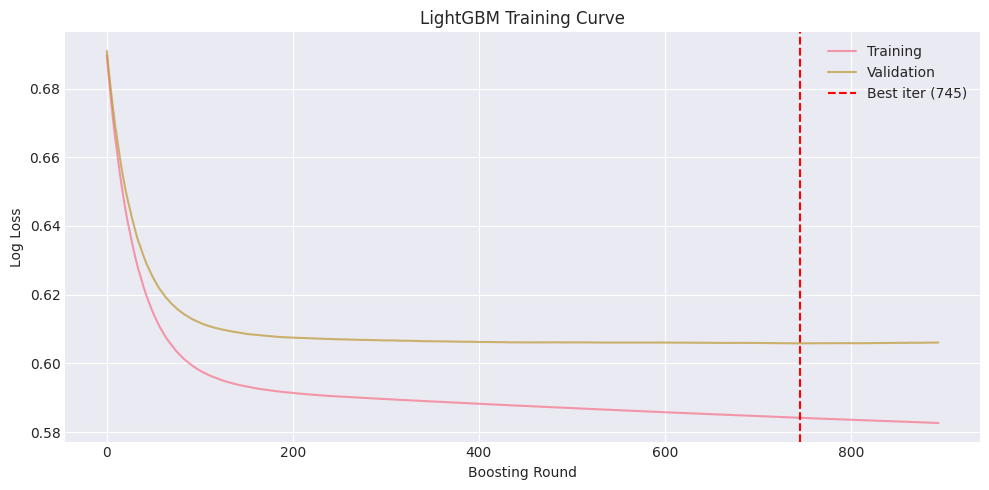

In [11]:
# LightGBM training curves
results_lgb = lgb_model.evals_result_

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results_lgb['training']['binary_logloss'], label='Training', alpha=0.7)
ax.plot(results_lgb['valid_1']['binary_logloss'], label='Validation', alpha=0.7)
ax.axvline(lgb_model.best_iteration_, color='red', linestyle='--',
           label=f'Best iter ({lgb_model.best_iteration_})')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('Log Loss')
ax.set_title('LightGBM Training Curve')
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# LightGBM tournament evaluation
lgb_preds_tourney = lgb_model.predict_proba(X_val_t)[:, 1]
lgb_brier = brier_score_loss(y_val_t, lgb_preds_tourney)
lgb_ll = log_loss(y_val_t, lgb_preds_tourney)
lgb_acc = accuracy_score(y_val_t, (lgb_preds_tourney > 0.5).astype(int))

print(f"LightGBM — 2025 Tournament:")
print(f"  Brier Score: {lgb_brier:.4f}")
print(f"  Log Loss:    {lgb_ll:.4f}")
print(f"  Accuracy:    {lgb_acc:.1%}")

LightGBM — 2025 Tournament:
  Brier Score: 0.1695
  Log Loss:    0.5077
  Accuracy:    79.1%


---
## 6. Individual Model Comparison

In [13]:
# Side-by-side comparison
comparison = pd.DataFrame({
    'Model': ['XGBoost', 'Logistic Regression', 'LightGBM'],
    'Brier Score': [xgb_brier, lr_brier, lgb_brier],
    'Log Loss': [xgb_ll, lr_ll, lgb_ll],
    'Accuracy': [xgb_acc, lr_acc, lgb_acc]
})

print("=" * 60)
print("Individual Model Results — 2025 Tournament")
print("=" * 60)
display(comparison.style.format({
    'Brier Score': '{:.4f}',
    'Log Loss': '{:.4f}',
    'Accuracy': '{:.1%}'
}).highlight_min(subset=['Brier Score', 'Log Loss'], color='lightgreen')
 .highlight_max(subset=['Accuracy'], color='lightgreen'))

# Prediction correlation between models
pred_corr = pd.DataFrame({
    'XGBoost': xgb_preds_tourney,
    'LogReg': lr_preds_tourney,
    'LightGBM': lgb_preds_tourney
}).corr()

print("\nPrediction correlation (lower = more diverse = better for blending):")
display(pred_corr.style.format('{:.3f}'))

Individual Model Results — 2025 Tournament


,Model,Brier Score,Log Loss,Accuracy
0,XGBoost,0.1705,0.5095,76.1%
1,Logistic Regression,0.1648,0.4974,77.6%
2,LightGBM,0.1695,0.5077,79.1%



Prediction correlation (lower = more diverse = better for blending):


,XGBoost,LogReg,LightGBM
XGBoost,1.000,0.990,0.999
LogReg,0.990,1.000,0.988
LightGBM,0.999,0.988,1.000


---
## 7. Ensemble Blend

Try multiple blend weights and pick the one with the best Brier score.

In [14]:
# Grid search over blend weights
best_brier = 1.0
best_weights = None
results = []

# Try weight combinations (step 0.1, must sum to 1.0)
for w_xgb in np.arange(0.0, 1.01, 0.1):
    for w_lr in np.arange(0.0, 1.01 - w_xgb, 0.1):
        w_lgb = round(1.0 - w_xgb - w_lr, 1)
        if w_lgb < 0:
            continue
        
        blend = w_xgb * xgb_preds_tourney + w_lr * lr_preds_tourney + w_lgb * lgb_preds_tourney
        brier = brier_score_loss(y_val_t, blend)
        ll = log_loss(y_val_t, blend)
        acc = accuracy_score(y_val_t, (blend > 0.5).astype(int))
        
        results.append({
            'w_XGB': round(w_xgb, 1), 'w_LR': round(w_lr, 1), 'w_LGB': round(w_lgb, 1),
            'Brier': brier, 'LogLoss': ll, 'Accuracy': acc
        })
        
        if brier < best_brier:
            best_brier = brier
            best_weights = (round(w_xgb, 1), round(w_lr, 1), round(w_lgb, 1))

results_df = pd.DataFrame(results).sort_values('Brier')

print("TOP 10 BLEND WEIGHTS (by Brier Score):")
print("=" * 70)
display(results_df.head(10).style.format({
    'Brier': '{:.4f}', 'LogLoss': '{:.4f}', 'Accuracy': '{:.1%}'
}))

print(f"\nBest blend: XGB={best_weights[0]}, LR={best_weights[1]}, LGB={best_weights[2]}")
print(f"Best Brier: {best_brier:.4f}")

TOP 10 BLEND WEIGHTS (by Brier Score):


,w_XGB,w_LR,w_LGB,Brier,LogLoss,Accuracy
10,0.000000,1.000000,0.000000,0.1648,0.4974,77.6%
9,0.000000,0.900000,0.100000,0.1652,0.4982,77.6%
20,0.100000,0.900000,0.000000,0.1653,0.4984,77.6%
8,0.000000,0.800000,0.200000,0.1655,0.4991,77.6%
19,0.100000,0.800000,0.100000,0.1657,0.4993,77.6%
29,0.200000,0.800000,0.000000,0.1658,0.4995,77.6%
7,0.000000,0.700000,0.300000,0.1659,0.5000,77.6%
18,0.100000,0.700000,0.200000,0.1661,0.5002,77.6%
28,0.200000,0.700000,0.100000,0.1662,0.5004,77.6%
37,0.300000,0.700000,-0.000000,0.1663,0.5006,77.6%



Best blend: XGB=0.0, LR=1.0, LGB=0.0
Best Brier: 0.1648


In [15]:
# Use the best blend weights
w_xgb, w_lr, w_lgb = best_weights

ensemble_preds_tourney = (w_xgb * xgb_preds_tourney +
                          w_lr * lr_preds_tourney +
                          w_lgb * lgb_preds_tourney)

ens_brier = brier_score_loss(y_val_t, ensemble_preds_tourney)
ens_ll = log_loss(y_val_t, ensemble_preds_tourney)
ens_acc = accuracy_score(y_val_t, (ensemble_preds_tourney > 0.5).astype(int))

print("=" * 60)
print("FINAL COMPARISON — 2025 Tournament")
print("=" * 60)

final_comparison = pd.DataFrame({
    'Model': ['XGBoost', 'Logistic Regression', 'LightGBM',
              f'ENSEMBLE ({w_xgb}/{w_lr}/{w_lgb})'],
    'Brier Score': [xgb_brier, lr_brier, lgb_brier, ens_brier],
    'Log Loss': [xgb_ll, lr_ll, lgb_ll, ens_ll],
    'Accuracy': [xgb_acc, lr_acc, lgb_acc, ens_acc]
})

display(final_comparison.style.format({
    'Brier Score': '{:.4f}',
    'Log Loss': '{:.4f}',
    'Accuracy': '{:.1%}'
}).highlight_min(subset=['Brier Score', 'Log Loss'], color='lightgreen')
 .highlight_max(subset=['Accuracy'], color='lightgreen'))

FINAL COMPARISON — 2025 Tournament


,Model,Brier Score,Log Loss,Accuracy
0,XGBoost,0.1705,0.5095,76.1%
1,Logistic Regression,0.1648,0.4974,77.6%
2,LightGBM,0.1695,0.5077,79.1%
3,ENSEMBLE (0.0/1.0/0.0),0.1648,0.4974,77.6%


---
## 8. Calibration & Distribution Plots

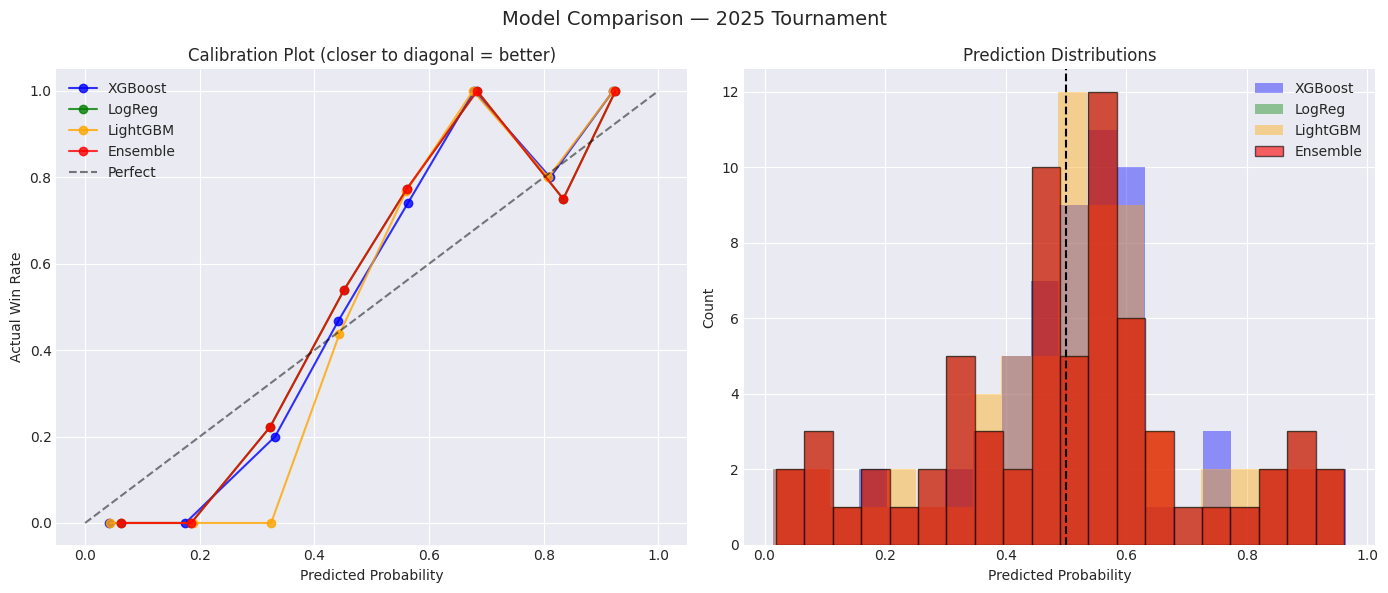

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Calibration curves for all models
for name, preds, color in [
    ('XGBoost', xgb_preds_tourney, 'blue'),
    ('LogReg', lr_preds_tourney, 'green'),
    ('LightGBM', lgb_preds_tourney, 'orange'),
    ('Ensemble', ensemble_preds_tourney, 'red')
]:
    prob_true, prob_pred = calibration_curve(y_val_t, preds, n_bins=8)
    axes[0].plot(prob_pred, prob_true, 'o-', label=name, color=color, alpha=0.8)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Actual Win Rate')
axes[0].set_title('Calibration Plot (closer to diagonal = better)')
axes[0].legend()

# Prediction distributions
axes[1].hist(xgb_preds_tourney, bins=20, alpha=0.4, label='XGBoost', color='blue')
axes[1].hist(lr_preds_tourney, bins=20, alpha=0.4, label='LogReg', color='green')
axes[1].hist(lgb_preds_tourney, bins=20, alpha=0.4, label='LightGBM', color='orange')
axes[1].hist(ensemble_preds_tourney, bins=20, alpha=0.6, label='Ensemble', color='red',
             edgecolor='black')
axes[1].axvline(0.5, color='black', linestyle='--')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Count')
axes[1].set_title('Prediction Distributions')
axes[1].legend()

plt.suptitle('Model Comparison — 2025 Tournament', fontsize=14)
plt.tight_layout()
plt.show()

---
## 9. Feature Importance Comparison

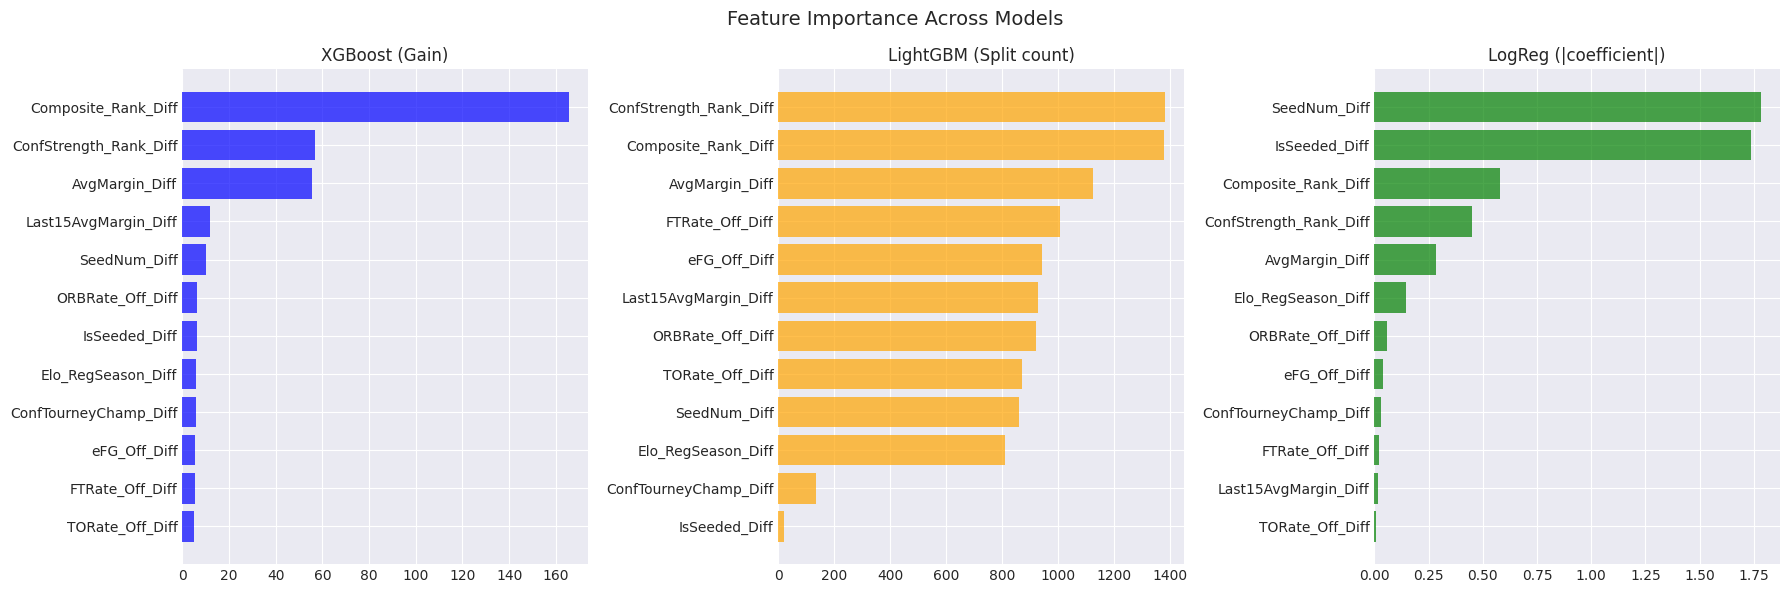

In [17]:
# Compare feature importance across all 3 models
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# XGBoost importance
xgb_imp = xgb_model.get_booster().get_score(importance_type='gain')
xgb_imp_df = pd.DataFrame({'Feature': xgb_imp.keys(), 'Importance': xgb_imp.values()}
                          ).sort_values('Importance', ascending=True)
axes[0].barh(xgb_imp_df['Feature'], xgb_imp_df['Importance'], alpha=0.7, color='blue')
axes[0].set_title('XGBoost (Gain)')

# LightGBM importance
lgb_imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': lgb_model.feature_importances_}
                          ).sort_values('Importance', ascending=True)
axes[1].barh(lgb_imp_df['Feature'], lgb_imp_df['Importance'], alpha=0.7, color='orange')
axes[1].set_title('LightGBM (Split count)')

# Logistic Regression weights (absolute)
lr_imp_df = pd.DataFrame({'Feature': feature_cols, 'Importance': np.abs(lr_model.coef_[0])}
                         ).sort_values('Importance', ascending=True)
axes[2].barh(lr_imp_df['Feature'], lr_imp_df['Importance'], alpha=0.7, color='green')
axes[2].set_title('LogReg (|coefficient|)')

plt.suptitle('Feature Importance Across Models', fontsize=14)
plt.tight_layout()
plt.show()

---
## 10. Generate 2026 Ensemble Submission

In [18]:
# Parse submission IDs
sub_matchups = []
for sub_id in sample_sub['ID']:
    season, team1, team2 = parse_submission_id(sub_id)
    sub_matchups.append({'ID': sub_id, 'Season': season, 'Team1': team1, 'Team2': team2})

sub_df = pd.DataFrame(sub_matchups)
print(f"Submission matchups: {len(sub_df):,}")

Submission matchups: 132,133


In [19]:
# Build features for 2026 (using 2025 team stats)
features_2025 = team_features[team_features['Season'] == 2025].copy()
print(f"Teams with 2025 stats: {len(features_2025)}")

diff_features = ['AvgMargin',
                 'eFG_Off', 'TORate_Off', 'ORBRate_Off', 'FTRate_Off',
                 'Elo_RegSeason', 'Composite_Rank',
                 'SeedNum', 'IsSeeded',
                 'ConfStrength_Rank', 'Last15AvgMargin', 'ConfTourneyChamp']

sub_features = []
missing_teams = set()

for _, row in sub_df.iterrows():
    t1 = features_2025[features_2025['TeamID'] == row['Team1']]
    t2 = features_2025[features_2025['TeamID'] == row['Team2']]
    
    feat_row = {'ID': row['ID']}
    
    if len(t1) == 0 or len(t2) == 0:
        if len(t1) == 0:
            missing_teams.add(row['Team1'])
        if len(t2) == 0:
            missing_teams.add(row['Team2'])
        for col in feature_cols:
            feat_row[col] = 0.0
        sub_features.append(feat_row)
        continue
    
    t1, t2 = t1.iloc[0], t2.iloc[0]
    for col in diff_features:
        val1, val2 = t1.get(col, np.nan), t2.get(col, np.nan)
        feat_row[f'{col}_Diff'] = val1 - val2 if pd.notna(val1) and pd.notna(val2) else 0.0
    
    sub_features.append(feat_row)

sub_feat_df = pd.DataFrame(sub_features)
X_sub = sub_feat_df[feature_cols].fillna(0.0)

print(f"Submission features built: {len(sub_feat_df):,}")
if missing_teams:
    print(f"Teams without 2025 data: {len(missing_teams)} (will predict ~0.5)")

Teams with 2025 stats: 364
Submission features built: 132,133
Teams without 2025 data: 364 (will predict ~0.5)


In [20]:
# Generate predictions from all 3 models
xgb_sub_preds = xgb_model.predict_proba(X_sub)[:, 1]
lr_sub_preds = lr_model.predict_proba(scaler.transform(X_sub))[:, 1]
lgb_sub_preds = lgb_model.predict_proba(X_sub)[:, 1]

# Blend with optimal weights
ensemble_preds = w_xgb * xgb_sub_preds + w_lr * lr_sub_preds + w_lgb * lgb_sub_preds

# Clip to avoid extreme values
ensemble_preds = np.clip(ensemble_preds, 0.01, 0.99)

print(f"Ensemble predictions (w_XGB={w_xgb}, w_LR={w_lr}, w_LGB={w_lgb}):")
print(f"  Mean: {ensemble_preds.mean():.3f}")
print(f"  Std:  {ensemble_preds.std():.3f}")
print(f"  Min:  {ensemble_preds.min():.3f}")
print(f"  Max:  {ensemble_preds.max():.3f}")

# Also show individual model stats for comparison
print(f"\nIndividual model prediction ranges:")
for name, preds in [('XGBoost', xgb_sub_preds), ('LogReg', lr_sub_preds), ('LightGBM', lgb_sub_preds)]:
    print(f"  {name}: mean={preds.mean():.3f}, std={preds.std():.3f}")

Ensemble predictions (w_XGB=0.0, w_LR=1.0, w_LGB=0.0):
  Mean: 0.492
  Std:  0.201
  Min:  0.010
  Max:  0.990

Individual model prediction ranges:
  XGBoost: mean=0.489, std=0.205
  LogReg: mean=0.492, std=0.201
  LightGBM: mean=0.491, std=0.204


In [21]:
# Build and validate submission
submission = pd.DataFrame({
    'ID': sub_feat_df['ID'],
    'Pred': ensemble_preds
})

validation_result = validate_submission(submission, sample_sub)
print(f"Valid: {validation_result['valid']}")
if validation_result['errors']:
    print(f"Errors: {validation_result['errors']}")

Valid: True


In [22]:
# Show top predicted matchups
sub_with_names = submission.copy()
parsed = sub_with_names['ID'].str.split('_', expand=True)
sub_with_names['Team1'] = parsed[1].astype(int)
sub_with_names['Team2'] = parsed[2].astype(int)
sub_with_names['Team1Name'] = sub_with_names['Team1'].map(team_lookup)
sub_with_names['Team2Name'] = sub_with_names['Team2'].map(team_lookup)

print("TOP 10: Team1 heavily favored:")
display(sub_with_names.sort_values('Pred', ascending=False)[['Team1Name', 'Team2Name', 'Pred']].head(10))

print("\nTOP 10: Team2 heavily favored:")
display(sub_with_names.sort_values('Pred', ascending=True)[['Team1Name', 'Team2Name', 'Pred']].head(10))

TOP 10: Team1 heavily favored:


,Team1Name,Team2Name,Pred
47135,Michigan St,MS Valley St,0.99
1265,Alabama,MS Valley St,0.99
6091,Auburn,Coppin St,0.99
34870,Houston,MS Valley St,0.99
38042,Iowa St,MS Valley St,0.99
28570,Florida,MS Valley St,0.99
47909,Missouri,MS Valley St,0.99
40594,Kentucky,MS Valley St,0.99
24340,Duke,MS Valley St,0.99
45335,Maryland,MS Valley St,0.99



TOP 10: Team2 heavily favored:


,Team1Name,Team2Name,Pred
4729,Ark Pine Bluff,Florida,0.010000
15433,Chicago St,Florida,0.010000
49500,MS Valley St,St John's,0.010000
19183,Coppin St,Florida,0.010000
49570,MS Valley St,Wisconsin,0.010000
49516,MS Valley St,Texas A&M,0.010000
19168,Coppin St,Duke,0.010000
49518,MS Valley St,Texas Tech,0.010000
49512,MS Valley St,Tennessee,0.010000
19207,Coppin St,Houston,0.010013


In [23]:
# Save ensemble submission
import os
sub_dir = PROCESSED_DIR.parent / 'submissions'
os.makedirs(sub_dir, exist_ok=True)

output_path = sub_dir / 'submission_ensemble_v1.csv'
submission.to_csv(output_path, index=False)
print(f"Saved: {output_path}")
print(f"Shape: {submission.shape}")
print(f"\nReady to upload to Kaggle!")

Saved: /home/sagemaker-user/NCAA/NCAA_March_Maddness-2026/submissions/submission_ensemble_v1.csv
Shape: (132133, 2)

Ready to upload to Kaggle!


---
## Summary

### Models
| Model | Type | Key Settings |
|-------|------|--------------|
| XGBoost | Gradient boosted trees (level-wise) | max_depth=4, lr=0.02, reg_alpha=0.5, reg_lambda=3.0 |
| Logistic Regression | Linear + sigmoid | C=0.5, StandardScaler |
| LightGBM | Gradient boosted trees (leaf-wise) | max_depth=4, lr=0.02, num_leaves=15 |

### Ensemble
- Weighted average blend of all 3 models
- Weights optimized via grid search on 2025 tournament Brier score
- Output: `submissions/submission_ensemble_v1.csv`

### Next Steps
- Try Optuna for hyperparameter tuning per model
- Add isotonic calibration on top of ensemble
- Re-run with 2026 regular season data when available (Stage 2)